# Customer Intelligence System

building an end-to-end pipeline — classification with RF and XGBoost, then some clustering to find natural groupings in the data. dataset is country-level socioeconomic indicators.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## loading the data

In [5]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')
print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [8]:
# checking for nulls
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## EDA

let's get a feel for the distributions before doing anything else

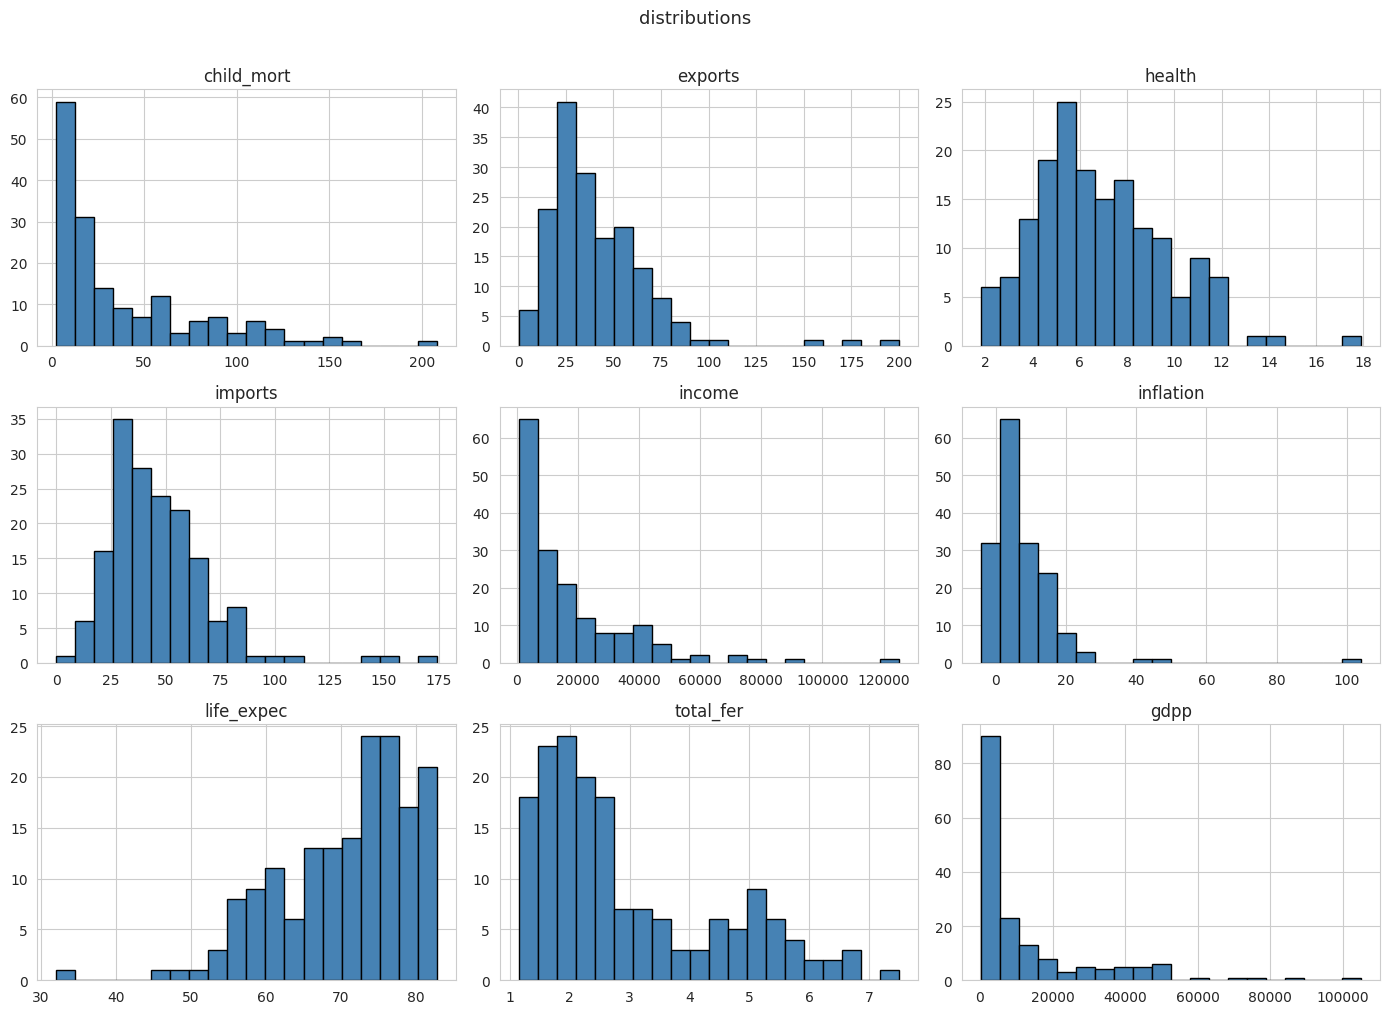

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

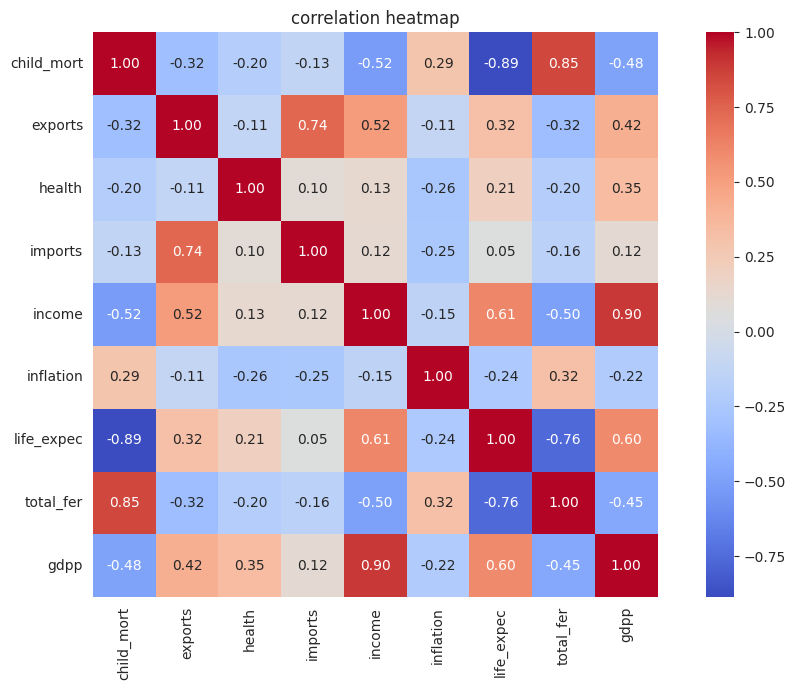

In [10]:
# correlation — gdpp and child_mort are obviously gonna be strongly linked
plt.figure(figsize=(10, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('correlation heatmap')
plt.tight_layout()
plt.show()

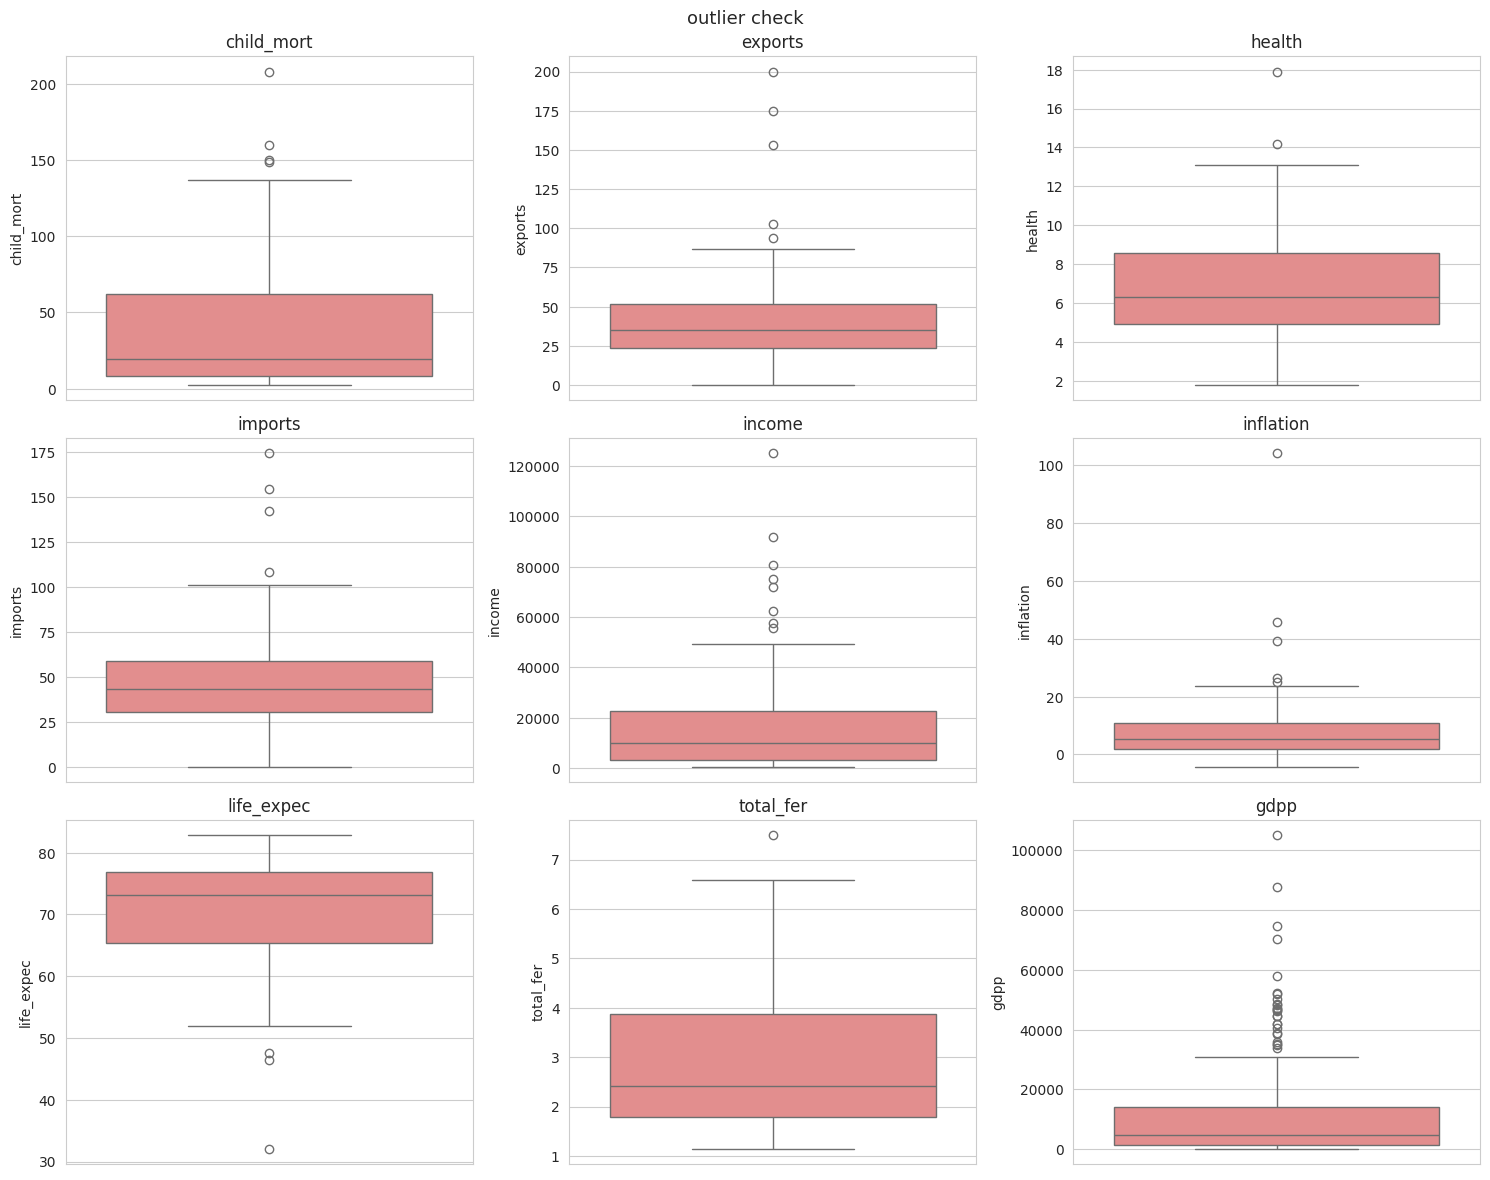

In [11]:
# boxplots to spot outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)

plt.suptitle('outlier check', fontsize=13)
plt.tight_layout()
plt.show()

## creating the target variable

no explicit label in the dataset so making one — countries with above-median gdpp AND below-median child mortality = developed (1), rest = developing (0). rough but reasonable.

In [12]:
gdpp_thresh  = df['gdpp'].median()
child_thresh = df['child_mort'].median()

df['target'] = ((df['gdpp'] >= gdpp_thresh) & (df['child_mort'] <= child_thresh)).astype(int)

print(df['target'].value_counts())
print(f'\n0 = developing  → {(df["target"]==0).sum()} countries')
print(f'1 = developed    → {(df["target"]==1).sum()} countries')

target
0    97
1    70
Name: count, dtype: int64

0 = developing  → 97 countries
1 = developed    → 70 countries


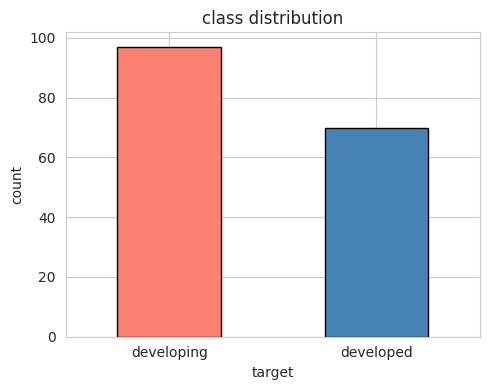

In [13]:
plt.figure(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.xticks([0, 1], ['developing', 'developed'], rotation=0)
plt.title('class distribution')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## preprocessing

scaling everything before feeding to models. using stratify to keep class ratio same in train/test

In [14]:
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[features]
y = df['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'train: {X_train.shape[0]} | test: {X_test.shape[0]}')

train: 133 | test: 34


## Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f'accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'roc-auc  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['developing', 'developed']))

accuracy : 1.0000
roc-auc  : 1.0000

              precision    recall  f1-score   support

  developing       1.00      1.00      1.00        20
   developed       1.00      1.00      1.00        14

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



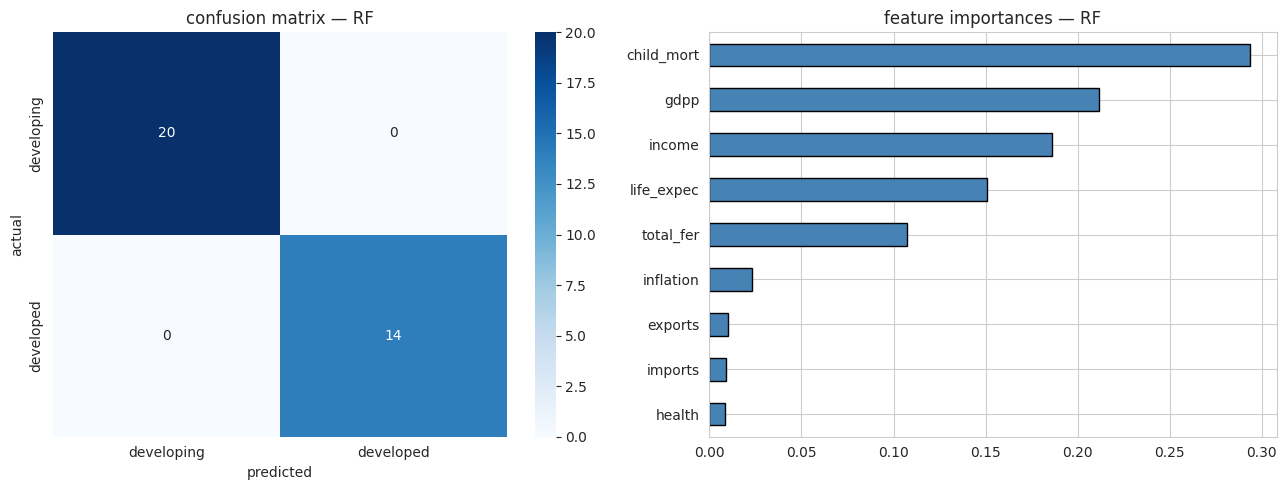

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['developing', 'developed'],
            yticklabels=['developing', 'developed'], ax=axes[0])
axes[0].set_title('confusion matrix — RF')
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('actual')

importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('feature importances — RF')

plt.tight_layout()
plt.show()

## XGBoost

In [17]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(f'accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'roc-auc  : {roc_auc_score(y_test, y_prob_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['developing', 'developed']))

accuracy : 1.0000
roc-auc  : 1.0000

              precision    recall  f1-score   support

  developing       1.00      1.00      1.00        20
   developed       1.00      1.00      1.00        14

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



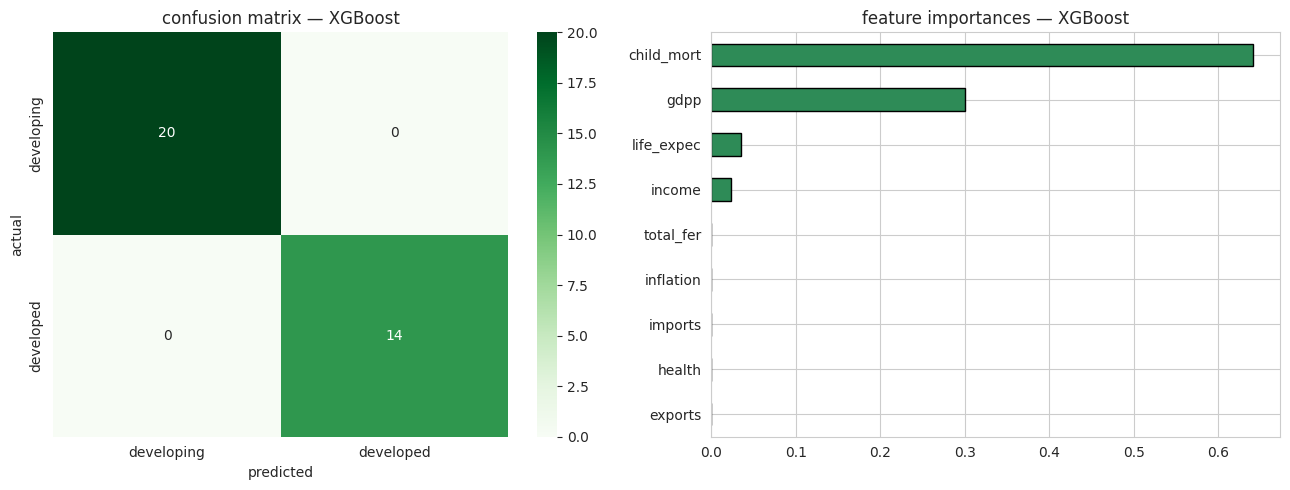

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['developing', 'developed'],
            yticklabels=['developing', 'developed'], ax=axes[0])
axes[0].set_title('confusion matrix — XGBoost')
axes[0].set_xlabel('predicted')
axes[0].set_ylabel('actual')

xgb_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('feature importances — XGBoost')

plt.tight_layout()
plt.show()

## ROC curve — comparing both models

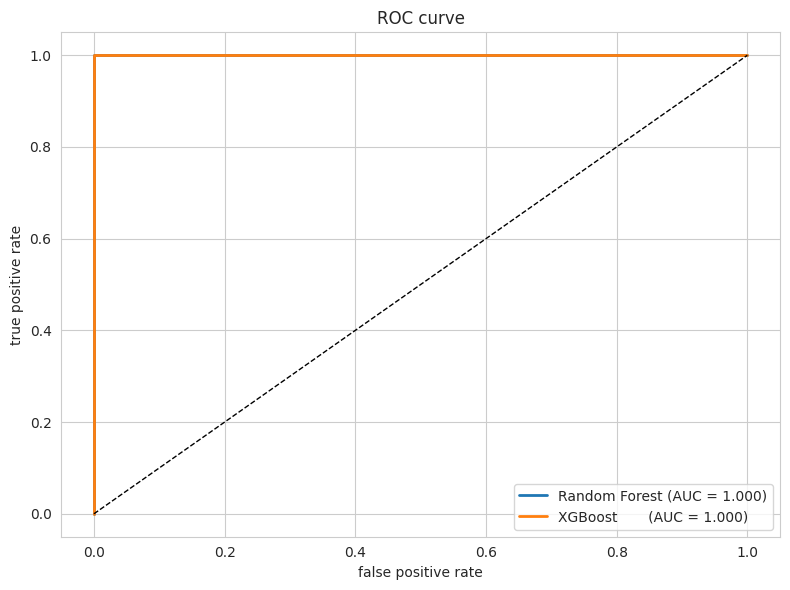

In [19]:
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})',  lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost       (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', lw=2)
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curve')
plt.legend()
plt.tight_layout()
plt.show()

## hyperparameter tuning — GridSearchCV on Random Forest

keeping the grid small since dataset is tiny, just checking a few key params

In [20]:
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print('best params:', grid_rf.best_params_)
print(f'best cv auc: {grid_rf.best_score_:.4f}')

best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
best cv auc: 0.9966


In [21]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(f'tuned RF → accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}  |  roc-auc: {roc_auc_score(y_test, y_prob_best_rf):.4f}')

tuned RF → accuracy: 1.0000  |  roc-auc: 1.0000


## cross-validation

In [22]:
cv_rf  = cross_val_score(best_rf, X_scaled, y, cv=5, scoring='roc_auc')
cv_xgb = cross_val_score(xgb,     X_scaled, y, cv=5, scoring='roc_auc')

print(f'RF    cv auc: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')
print(f'XGB   cv auc: {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

RF    cv auc: 0.9970 ± 0.0044
XGB   cv auc: 0.9962 ± 0.0048


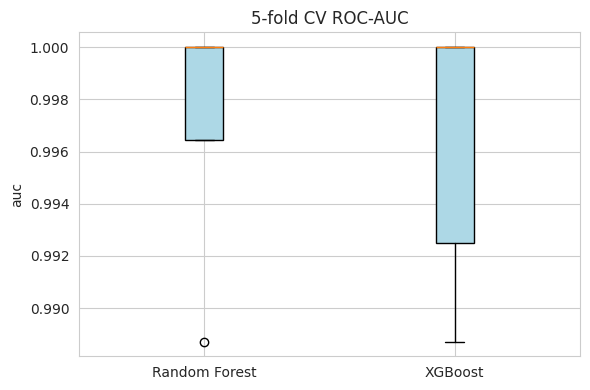

In [23]:
plt.figure(figsize=(6, 4))
plt.boxplot([cv_rf, cv_xgb], labels=['Random Forest', 'XGBoost'],
            patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('5-fold CV ROC-AUC')
plt.ylabel('auc')
plt.tight_layout()
plt.show()

## clustering — K-Means

using elbow + silhouette to pick k. silhouette is usually more reliable than just eyeballing the elbow

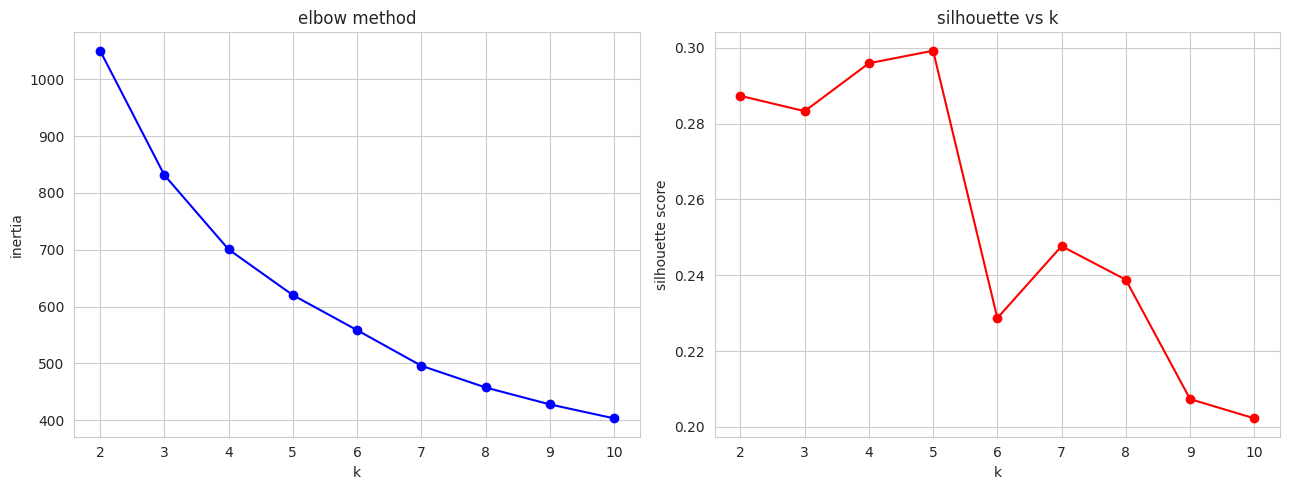

best k by silhouette: 5


In [24]:
inertia    = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('elbow method')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('silhouette vs k')

plt.tight_layout()
plt.show()

print(f'best k by silhouette: {list(K_range)[np.argmax(sil_scores)]}')

In [25]:
optimal_k = list(K_range)[np.argmax(sil_scores)]

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f'k = {optimal_k}')
print(f'silhouette: {silhouette_score(X_scaled, df["kmeans_cluster"]):.4f}')
print()
print(df['kmeans_cluster'].value_counts().sort_index())

k = 5
silhouette: 0.2993

kmeans_cluster
0    84
1    47
2     3
3    32
4     1
Name: count, dtype: int64


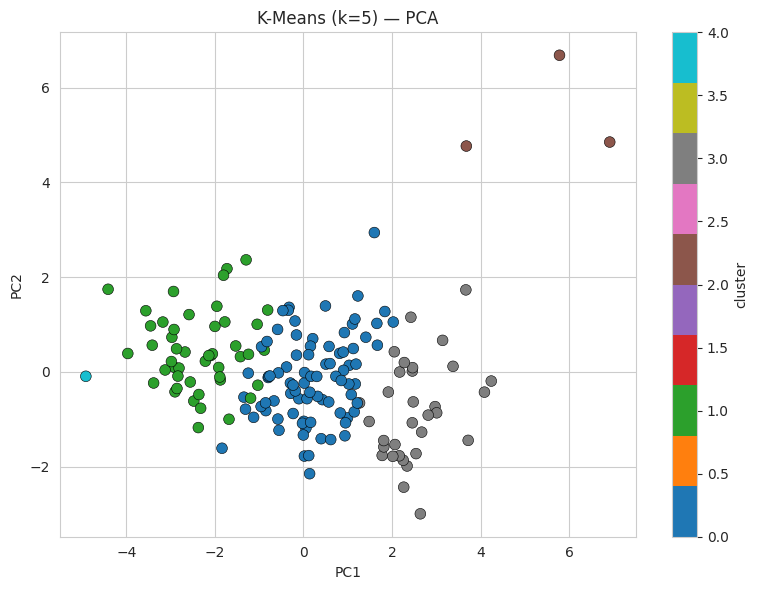

In [26]:
# reduce to 2d with PCA for plotting
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['kmeans_cluster'], cmap='tab10', s=60, edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, label='cluster')
plt.title(f'K-Means (k={optimal_k}) — PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

In [27]:
# average feature values per cluster
cluster_profile = df.groupby('kmeans_cluster')[features].mean().round(2)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


## clustering — DBSCAN

eps and min_samples tuned manually — tried a few values, 1.5 / 4 gave decent results without classifying half the data as noise

In [28]:
dbscan = DBSCAN(eps=1.5, min_samples=4)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise       = (df['dbscan_cluster'] == -1).sum()

print(f'clusters found : {n_clusters_db}')
print(f'noise points   : {n_noise}')
print()
print(df['dbscan_cluster'].value_counts().sort_index())

if n_clusters_db > 1:
    mask  = df['dbscan_cluster'] != -1
    sil_db = silhouette_score(X_scaled[mask], df['dbscan_cluster'][mask])
    print(f'\nsilhouette (excl. noise): {sil_db:.4f}')

clusters found : 1
noise points   : 29

dbscan_cluster
-1     29
 0    138
Name: count, dtype: int64


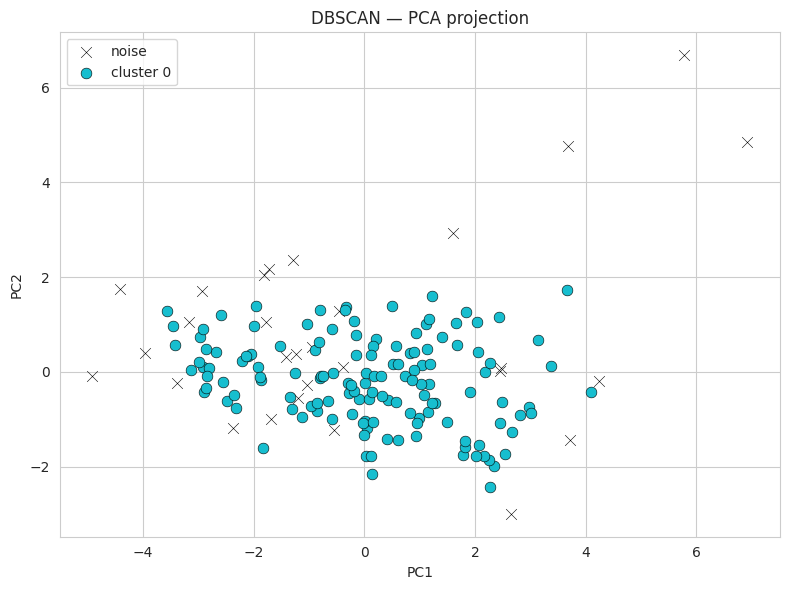

In [29]:
plt.figure(figsize=(8, 6))
unique_labels = sorted(df['dbscan_cluster'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = df['dbscan_cluster'] == label
    lbl  = 'noise' if label == -1 else f'cluster {label}'
    clr  = 'black' if label == -1 else color
    mk   = 'x'     if label == -1 else 'o'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[clr], label=lbl,
                s=60, marker=mk, edgecolors='k' if label != -1 else None, linewidths=0.4)

plt.title('DBSCAN — PCA projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## cluster profiles

radar chart gives a better visual sense of how clusters differ across all features at once

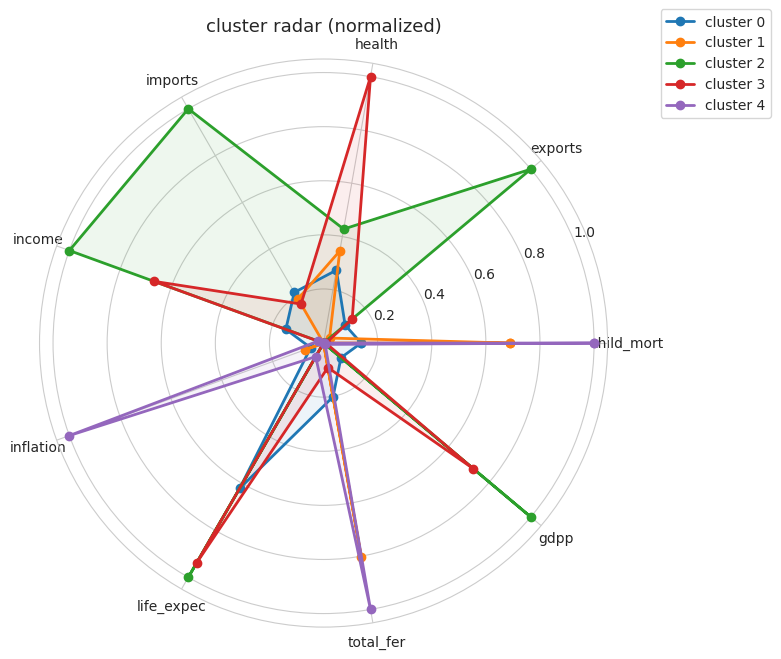

In [30]:
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

angles  = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
cmap    = plt.cm.tab10

for i, row in profile_norm.iterrows():
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=f'cluster {i}', color=cmap(i))
    ax.fill(angles, vals, alpha=0.08, color=cmap(i))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, size=10)
ax.set_title('cluster radar (normalized)', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [31]:
# top countries per cluster by gdpp
df[['country', 'gdpp', 'child_mort', 'life_expec', 'income', 'kmeans_cluster']]\
    .sort_values('gdpp', ascending=False)\
    .head(10)

,country,gdpp,child_mort,life_expec,income,kmeans_cluster
91,Luxembourg,105000,2.8,81.3,91700,2
114,Norway,87800,3.2,81.0,62300,3
145,Switzerland,74600,4.5,82.2,55500,3
123,Qatar,70300,9.0,79.5,125000,3
44,Denmark,58000,4.1,79.5,44000,3
144,Sweden,52100,3.0,81.5,42900,3
7,Australia,51900,4.8,82.0,41400,3
110,Netherlands,50300,4.5,80.7,45500,3
73,Ireland,48700,4.2,80.4,45700,3
159,United States,48400,7.3,78.7,49400,3


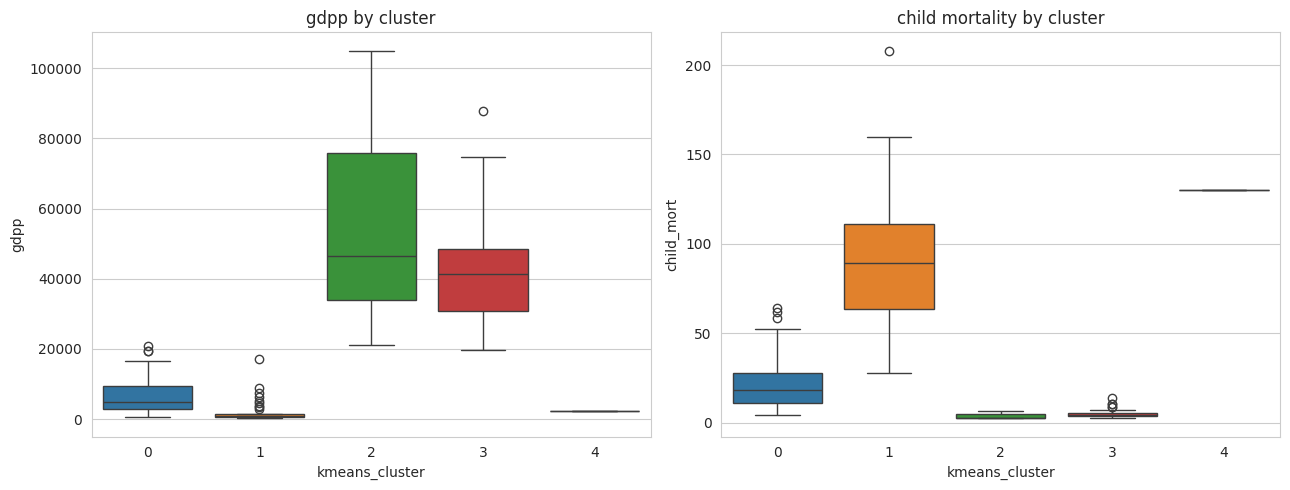

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x='kmeans_cluster', y='gdpp',       data=df, palette='tab10', ax=axes[0])
sns.boxplot(x='kmeans_cluster', y='child_mort', data=df, palette='tab10', ax=axes[1])

axes[0].set_title('gdpp by cluster')
axes[1].set_title('child mortality by cluster')

plt.tight_layout()
plt.show()

## final summary

In [33]:
summary = pd.DataFrame({
    'model':          ['Random Forest', 'Tuned Random Forest', 'XGBoost'],
    'accuracy':       [accuracy_score(y_test, y_pred_rf),
                       accuracy_score(y_test, y_pred_best_rf),
                       accuracy_score(y_test, y_pred_xgb)],
    'roc_auc_test':   [roc_auc_score(y_test, y_prob_rf),
                       roc_auc_score(y_test, y_prob_best_rf),
                       roc_auc_score(y_test, y_prob_xgb)],
    'cv_auc_mean':    [cv_rf.mean(), np.nan, cv_xgb.mean()]
}).round(4)

summary

,model,accuracy,roc_auc_test,cv_auc_mean
0,Random Forest,1.0,1.0,0.9970
1,Tuned Random Forest,1.0,1.0,NaN
2,XGBoost,1.0,1.0,0.9962


In [34]:
cluster_summary = pd.DataFrame({
    'algorithm':       ['K-Means', 'DBSCAN'],
    'clusters':        [optimal_k, n_clusters_db],
    'silhouette':      [round(silhouette_score(X_scaled, df['kmeans_cluster']), 4),
                        round(sil_db, 4) if n_clusters_db > 1 else 'N/A'],
    'noise_points':    [0, n_noise]
})

cluster_summary

,algorithm,clusters,silhouette,noise_points
0,K-Means,5,0.2993,0
1,DBSCAN,1,N/A,29
